# S&P 500 Sektor ETF'leri — Makroekonomik Olay Calismasi
## Kesifsel Veri Analizi (EDA), Istatistiksel Testler ve Baseline ML Modeli

Bu defterda asagidaki adimlari gerceklestiriyoruz:
1. **Veri Temizligi ve Anormal Getiri (AR) Hazirligi**
2. **Olay Penceresi Gorsellestirmeleri (CAR & Volatilite Soku)**
3. **Korelasyon ve Dagilim Analizi**
4. **Istatistiksel Cikarim — Hipotez Testi**
5. **Baseline RandomForest Modeli ve Ozellik Onemi**

---
## Hucre 0 — Kutuphane Yuklemeleri ve Genel Ayarlar

In [ ]:
# ======================================================
# Gerekli kutuphaneleri ice aktar
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings("ignore")

# Gorsel tema ayari
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Kutuphaneler basariyla yuklendi.")

Kutuphaneler basariyla yuklendi.


---
## Gorev 1 — Veri Temizligi ve Anormal Getiri (AR) Hazirligi

In [ ]:
# ======================================================
# 1-A) Veriyi oku ve ilk bakis
# ======================================================
dosya_yolu = "sp500_olay_calismasi_ham_veri.csv"   
df_ham = pd.read_csv(dosya_yolu)

print(f"Veri boyutu: {df_ham.shape[0]} satir x {df_ham.shape[1]} sutun")
print("\nSutun tipleri:")
print(df_ham.dtypes)
df_ham.head()

Veri boyutu: 17520 satir x 13 sutun

Sutun tipleri:
Tarih                   object
Olay_Ismi               object
Hisse                   object
Grup                    object
T0_Goreceli_Gun          int64
Duzeltilmis_Kapanis    float64
Log_Getiri             float64
Volatilite_10g         float64
Volatilite_30g         float64
Log_Hacim              float64
Hacim_Degisimi         float64
RSI_14                 float64
SMA_Uzaklik_20         float64
dtype: object


,Tarih,Olay_Ismi,Hisse,Grup,T0_Goreceli_Gun,Duzeltilmis_Kapanis,Log_Getiri,Volatilite_10g,Volatilite_30g,Log_Hacim,Hacim_Degisimi,RSI_14,SMA_Uzaklik_20
0,2015-11-16,ABD_Secimleri_2016,CL=F,Emtia_Makro,-358,41.740002,0.024249,0.024750,0.025493,13.190358,0.112886,37.6284,-0.063695
1,2015-11-17,ABD_Secimleri_2016,CL=F,Emtia_Makro,-357,40.669998,-0.025969,0.018598,0.023880,12.804126,-0.320388,34.4149,-0.082676
2,2015-11-18,ABD_Secimleri_2016,CL=F,Emtia_Makro,-356,40.750000,0.001965,0.018342,0.023859,12.435274,-0.308473,34.8628,-0.076236
3,2015-11-19,ABD_Secimleri_2016,CL=F,Emtia_Makro,-355,40.540001,-0.005167,0.017990,0.022716,11.785674,-0.477747,34.2025,-0.075927
4,2015-11-20,ABD_Secimleri_2016,CL=F,Emtia_Makro,-354,40.389999,-0.003707,0.017786,0.022635,12.977668,2.293660,33.7113,-0.074908


In [17]:
# ======================================================
# 1-B) inf / -inf temizligi  (Hacim_Degisimi sutunu)
# ======================================================
# Sonsuz degerleri NaN yap, sonra ileri doldur (ffill)
df_ham["Hacim_Degisimi"] = df_ham["Hacim_Degisimi"].replace([np.inf, -np.inf], np.nan)
df_ham["Hacim_Degisimi"] = df_ham["Hacim_Degisimi"].ffill()

# Genel eksik veri kontrolu
eksik = df_ham.isnull().sum()
print("Eksik deger sayilari (> 0 olanlar):")
print(eksik[eksik > 0] if eksik.sum() > 0 else "Hic eksik deger yok.")

Eksik deger sayilari (> 0 olanlar):
Hic eksik deger yok.


In [18]:
# ======================================================
# 1-C) SPY (Gosterge Endeks) satirlarini ayir
# ======================================================
df_spy = df_ham[
    (df_ham["Grup"] == "Gosterge_Endeks") & (df_ham["Hisse"] == "SPY")
].copy()

# SPY getirilerini birlestime hazirla:
# Anahtar = (Tarih, Olay_Ismi) ikilisi
df_spy_getiri = df_spy[["Tarih", "Olay_Ismi", "Log_Getiri"]].rename(
    columns={"Log_Getiri": "SPY_Log_Getiri"}
)

print(f"SPY satir sayisi: {len(df_spy)}")
df_spy_getiri.head()

SPY satir sayisi: 1593


,Tarih,Olay_Ismi,SPY_Log_Getiri
954,2015-11-16,ABD_Secimleri_2016,0.015092
955,2015-11-17,ABD_Secimleri_2016,-0.000729
956,2015-11-18,ABD_Secimleri_2016,0.015741
957,2015-11-19,ABD_Secimleri_2016,-0.000863
958,2015-11-20,ABD_Secimleri_2016,0.003637


In [19]:
# ======================================================
# 1-D) Sektor hisselerini filtrele ve Anormal Getiri hesapla
# ======================================================
# SPY haric tum satirlar
df_sektor = df_ham[df_ham["Hisse"] != "SPY"].copy()

# SPY getirisini ayni (Tarih, Olay_Ismi) eslemesiyle birlestir
df_sektor = df_sektor.merge(df_spy_getiri, on=["Tarih", "Olay_Ismi"], how="left")

# Anormal Getiri = Hisse Log_Getiri - SPY Log_Getiri
df_sektor["Anormal_Getiri"] = df_sektor["Log_Getiri"] - df_sektor["SPY_Log_Getiri"]

print(f"Sektor veri boyutu: {df_sektor.shape}")
print(f"Benzersiz hisseler : {df_sektor['Hisse'].unique()}")
print(f"\nAnormal_Getiri istatistikleri:")
df_sektor["Anormal_Getiri"].describe()

Sektor veri boyutu: (15927, 15)
Benzersiz hisseler : ['CL=F' 'GLD' 'ITA' 'XLE' 'XLF' 'XLK' 'XLP' 'XLRE' 'XLV' 'XLY']

Anormal_Getiri istatistikleri:


count    15927.000000
mean        -0.000115
std          0.013311
min         -0.296112
25%         -0.004919
50%          0.000000
75%          0.004580
max          0.297682
Name: Anormal_Getiri, dtype: float64

---
## Gorev 2 — Olay Penceresi Gorsellestirmeleri

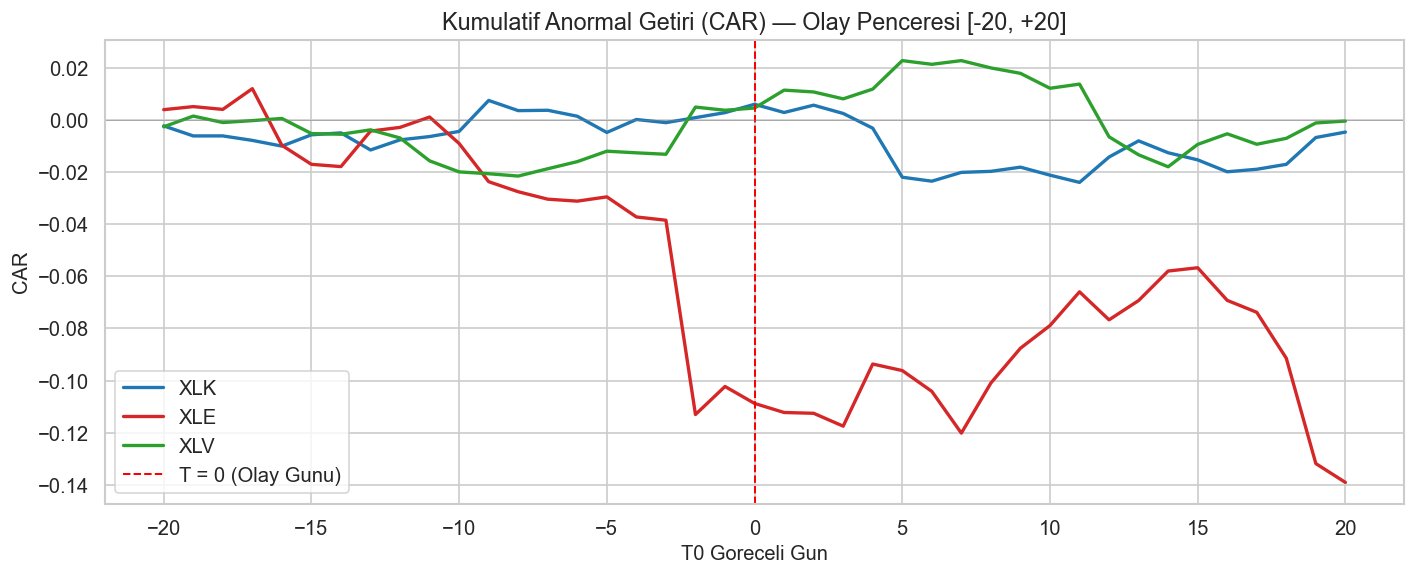

In [20]:
# ======================================================
# 2-A) CAR Grafigi  [-20, +20] olay penceresi
# ======================================================
# Sadece [-20, 20] gun araligini al
olay_penceresi = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -20) & (df_sektor["T0_Goreceli_Gun"] <= 20)
].copy()

# Ilgilendigimiz uc sektor ETF'i
hedef_hisseler = ["XLK", "XLE", "XLV"]
renk_haritasi = {"XLK": "#1f77b4", "XLE": "#d62728", "XLV": "#2ca02c"}

fig, ax = plt.subplots(figsize=(12, 5))

for hisse in hedef_hisseler:
    # Hisseye ait verileri al
    alt_df = olay_penceresi[olay_penceresi["Hisse"] == hisse].copy()

    # Her (Olay, T0_Goreceli_Gun) icin ortalama Anormal Getiri
    ort_ar = (
        alt_df.groupby("T0_Goreceli_Gun")["Anormal_Getiri"]
        .mean()
        .sort_index()
    )

    # Kumulatif Anormal Getiri (CAR)
    car = ort_ar.cumsum()

    ax.plot(
        car.index, car.values,
        label=hisse, color=renk_haritasi[hisse], linewidth=2
    )

# T=0 dikey cizgisi
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, label="T = 0 (Olay Gunu)")
ax.axhline(y=0, color="grey", linestyle="-", linewidth=0.5, alpha=0.6)

ax.set_title("Kumulatif Anormal Getiri (CAR) — Olay Penceresi [-20, +20]")
ax.set_xlabel("T0 Goreceli Gun")
ax.set_ylabel("CAR")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

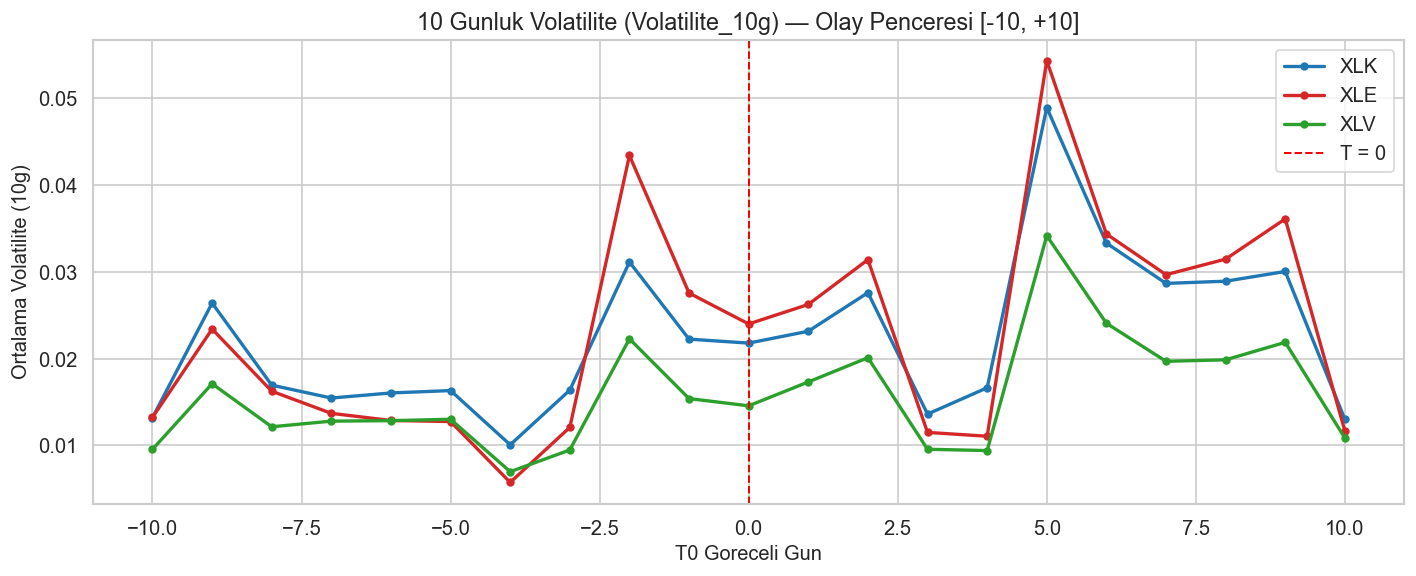

In [21]:
# ======================================================
# 2-B) Volatilite Soku Grafigi  [-10, +10]
# ======================================================
vol_penceresi = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -10) & (df_sektor["T0_Goreceli_Gun"] <= 10)
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for hisse in hedef_hisseler:
    alt_df = vol_penceresi[vol_penceresi["Hisse"] == hisse]
    ort_vol = (
        alt_df.groupby("T0_Goreceli_Gun")["Volatilite_10g"]
        .mean()
        .sort_index()
    )
    ax.plot(
        ort_vol.index, ort_vol.values,
        label=hisse, color=renk_haritasi[hisse],
        linewidth=2, marker="o", markersize=4
    )

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, label="T = 0")

ax.set_title("10 Gunluk Volatilite (Volatilite_10g) — Olay Penceresi [-10, +10]")
ax.set_xlabel("T0 Goreceli Gun")
ax.set_ylabel("Ortalama Volatilite (10g)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

---
## Gorev 3 — Korelasyon ve Dagilim Analizi

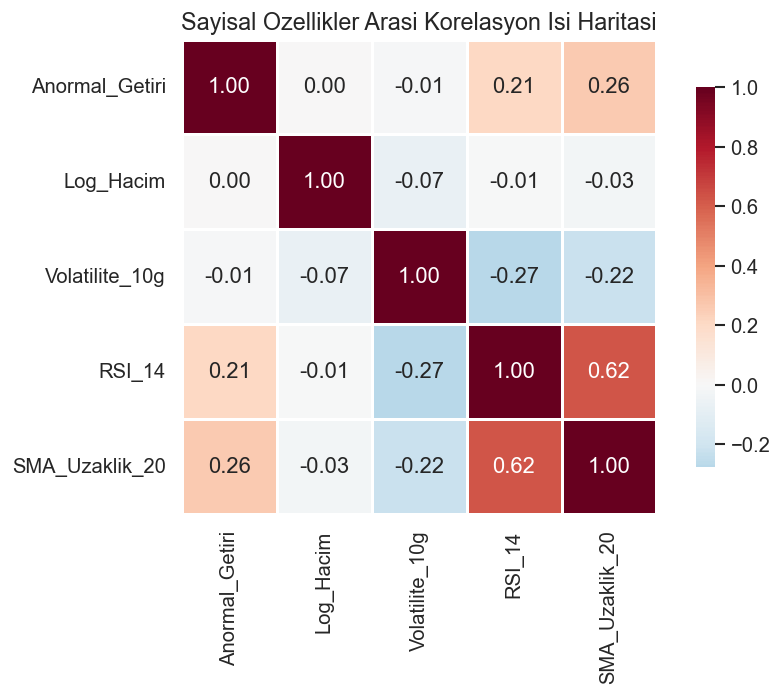

In [22]:
# ======================================================
# 3-A) Korelasyon Isi Haritasi
# ======================================================
kor_sutunlar = ["Anormal_Getiri", "Log_Hacim", "Volatilite_10g", "RSI_14", "SMA_Uzaklik_20"]

kor_matrisi = df_sektor[kor_sutunlar].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    kor_matrisi,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Sayisal Ozellikler Arasi Korelasyon Isi Haritasi")
plt.tight_layout()
plt.show()

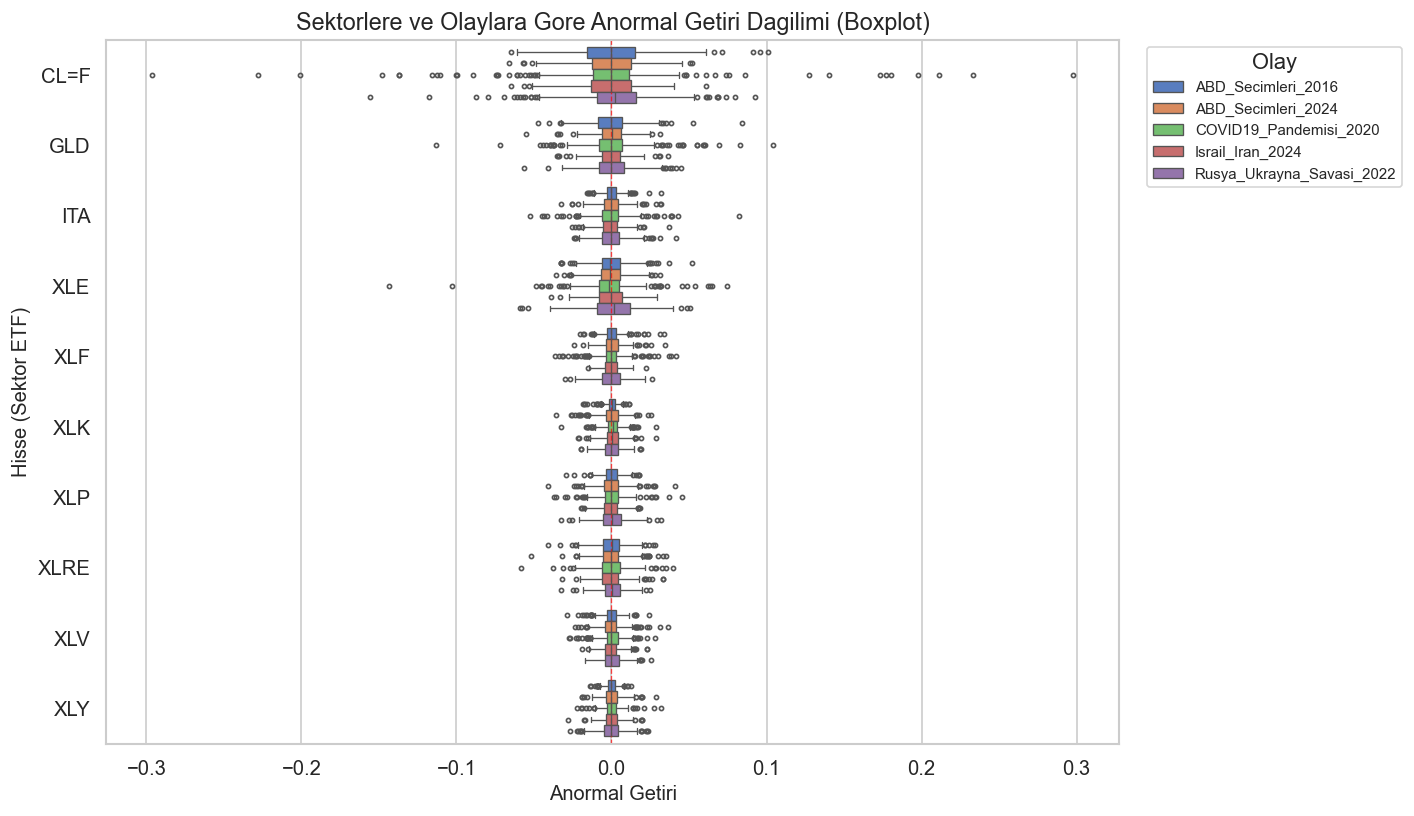

In [23]:
# ======================================================
# 3-B) Sektorlerin Anormal Getiri Dagilimi — Yatay Boxplot
# ======================================================
# Sadece sektor ETF'lerini al (Emtia/Makro haric tutmak isterseniz filtreleyebilirsiniz)
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_sektor,
    y="Hisse",
    x="Anormal_Getiri",
    hue="Olay_Ismi",
    orient="h",
    fliersize=2.5,
    linewidth=0.8,
    ax=ax,
)

ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Sektorlere ve Olaylara Gore Anormal Getiri Dagilimi (Boxplot)")
ax.set_xlabel("Anormal Getiri")
ax.set_ylabel("Hisse (Sektor ETF)")
ax.legend(title="Olay", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---
## Gorev 4 — Istatistiksel Cikarim (Hipotez Testi)

In [24]:
# ======================================================
# 4) Tek Orneklem T-Testi  (Olay gunu T=0)
# ======================================================
# Olay gunundeki anormal getirileri filtrele
ar_t0 = df_sektor.loc[
    df_sektor["T0_Goreceli_Gun"] == 0, "Anormal_Getiri"
].dropna()

# H0 : mu(AR) = 0  (Olaylarin anormal getiri uzerinde etkisi yoktur)
# H1 : mu(AR) != 0
t_ist, p_deger = stats.ttest_1samp(ar_t0, popmean=0)

print("=" * 55)
print("TEK ORNEKLEM T-TESTI  (T0 = 0 gunu, Anormal Getiri)")
print("=" * 55)
print(f"Gozlem sayisi (n)      : {len(ar_t0)}")
print(f"Ortalama AR            : {ar_t0.mean():.6f}")
print(f"Standart Sapma         : {ar_t0.std():.6f}")
print(f"t-istatistigi          : {t_ist:.4f}")
print(f"p-degeri (two-tailed)  : {p_deger:.6f}")
print("-" * 55)

alfa = 0.05
if p_deger < alfa:
    print(
        f"SONUC: p = {p_deger:.6f} < {alfa}  →  H0 REDDEDILIR.\n"
        "Olay gununde gozlemlenen anormal getiriler istatistiksel\n"
        "olarak anlamli derecede sifirdan farklidir. Yani olaylarin\n"
        "sektor getirileri uzerinde sans eseri olmayan bir etkisi vardir."
    )
else:
    print(
        f"SONUC: p = {p_deger:.6f} >= {alfa}  →  H0 REDDEDILEMEZ.\n"
        "Olay gunundeki anormal getiriler istatistiksel olarak\n"
        "sifirdan anlamli farklilik gostermemektedir. Gozlemlenen\n"
        "fark sans eseri olabilir."
    )

TEK ORNEKLEM T-TESTI  (T0 = 0 gunu, Anormal Getiri)
Gozlem sayisi (n)      : 50
Ortalama AR            : -0.001284
Standart Sapma         : 0.014103
t-istatistigi          : -0.6436
p-degeri (two-tailed)  : 0.522864
-------------------------------------------------------
SONUC: p = 0.522864 >= 0.05  →  H0 REDDEDILEMEZ.
Olay gunundeki anormal getiriler istatistiksel olarak
sifirdan anlamli farklilik gostermemektedir. Gozlemlenen
fark sans eseri olabilir.


In [ ]:
# ======================================================
# 4-B) SEKTOR BAZLI T-TESTI  (T0 = 0, her sektor icin ayri)
# ======================================================
# Her bir sektor ETF'i icin T=0 (olay gunu) anormal getirilerinin
# ortalamasinin sifirdan farkli olup olmadigini test ediyoruz.
# H0: mu(AR_i) = 0  (sektor i icin olay etkisi yoktur)
# H1: mu(AR_i) != 0
sektor_t0 = []
for h in sorted(df_sektor["Hisse"].unique()):
    a = df_sektor[(df_sektor["Hisse"] == h) &
                  (df_sektor["T0_Goreceli_Gun"] == 0)]["Anormal_Getiri"].dropna()
    g = df_sektor[df_sektor["Hisse"] == h]["Grup"].iloc[0]
    t_, p_ = stats.ttest_1samp(a, popmean=0)
    sektor_t0.append({
        "Hisse": h, "Grup": g, "n": len(a),
        "Ortalama_AR_T0": a.mean(), "Std_AR_T0": a.std(),
        "t_istatistik": t_, "p_deger": p_,
        "Anlamli_p05": "EVET" if p_ < 0.05 else "Hayir",
    })

sektor_t0_df = (pd.DataFrame(sektor_t0)
                .sort_values("p_deger")
                .reset_index(drop=True))

print("SEKTOR BAZLI TEK-ORNEKLEM T-TESTI  (T0 = 0 gunu)")
print("=" * 85)
print(sektor_t0_df.to_string(index=False,
      formatters={"Ortalama_AR_T0": "{:.6f}".format,
                  "Std_AR_T0":      "{:.6f}".format,
                  "t_istatistik":   "{:.4f}".format,
                  "p_deger":        "{:.6f}".format}))


In [ ]:
# ======================================================
# 4-C) SEKTOR BAZLI CAR [-3, +3] T-TESTI
# ======================================================
# Olay gunu tek bir gundur; buna karsilik olayin piyasaya tam yansimasi
# birkac gun surebilir. Bu yuzden her (Sektor, Olay) ciftinin [-3, +3]
# penceresindeki Kumulatif Anormal Getirisini (CAR) hesaplayip,
# sektor bazinda mu(CAR) = 0 hipotezini test ediyoruz.
car_penceresi = df_sektor[df_sektor["T0_Goreceli_Gun"].between(-3, 3)]
car_df = (car_penceresi
          .groupby(["Hisse", "Olay_Ismi", "Grup"])["Anormal_Getiri"]
          .sum()
          .reset_index()
          .rename(columns={"Anormal_Getiri": "CAR"}))

sektor_car = []
for h in sorted(car_df["Hisse"].unique()):
    a = car_df[car_df["Hisse"] == h]["CAR"]
    g = car_df[car_df["Hisse"] == h]["Grup"].iloc[0]
    t_, p_ = stats.ttest_1samp(a, popmean=0)
    sektor_car.append({
        "Hisse": h, "Grup": g, "n_olay": len(a),
        "Ortalama_CAR": a.mean(), "Std_CAR": a.std(),
        "t_istatistik": t_, "p_deger": p_,
        "Anlamli_p05": "EVET" if p_ < 0.05 else "Hayir",
    })

sektor_car_df = (pd.DataFrame(sektor_car)
                 .sort_values("p_deger")
                 .reset_index(drop=True))

print("SEKTOR BAZLI CAR [-3, +3] T-TESTI")
print("=" * 85)
print(sektor_car_df.to_string(index=False,
      formatters={"Ortalama_CAR": "{:.6f}".format,
                  "Std_CAR":      "{:.6f}".format,
                  "t_istatistik": "{:.4f}".format,
                  "p_deger":      "{:.6f}".format}))


In [ ]:
# ======================================================
# 4-D) GENIS PENCERE [-10, +10]  -  Havuzlanmis Gunluk AR T-Testi
# ======================================================
# Her sektor icin olay penceresindeki tum gunluk AR gozlemleri (21 gun x 5 olay
# = 75 gozlem/sektor) havuzlanarak ortalamanin sifirdan farki test edilir.
# Bu test ornek buyuklugunu artirir ve istatistiksel gucu yukseltir.
sektor_wide = []
for h in sorted(df_sektor["Hisse"].unique()):
    a = df_sektor[(df_sektor["Hisse"] == h) &
                  (df_sektor["T0_Goreceli_Gun"].between(-10, 10))]["Anormal_Getiri"].dropna()
    g = df_sektor[df_sektor["Hisse"] == h]["Grup"].iloc[0]
    t_, p_ = stats.ttest_1samp(a, popmean=0)
    sektor_wide.append({
        "Hisse": h, "Grup": g, "n": len(a),
        "Ortalama_AR_pencere": a.mean(),
        "t_istatistik": t_, "p_deger": p_,
        "Anlamli_p05": "EVET" if p_ < 0.05 else "Hayir",
    })

sektor_wide_df = (pd.DataFrame(sektor_wide)
                  .sort_values("p_deger")
                  .reset_index(drop=True))

print("SEKTOR BAZLI GENIS PENCERE [-10, +10]  HAVUZLANMIS T-TESTI")
print("=" * 85)
print(sektor_wide_df.to_string(index=False,
      formatters={"Ortalama_AR_pencere": "{:.6f}".format,
                  "t_istatistik":        "{:.4f}".format,
                  "p_deger":             "{:.6f}".format}))


In [ ]:
# ======================================================
# 4-E) Sektor Bazli Ortalama CAR Grafigi  (p-degerleri ile)
# ======================================================
fig, ax = plt.subplots(figsize=(11, 6))
dfp = sektor_car_df.sort_values("Ortalama_CAR")
renk = ["#2ca02c" if v > 0 else "#d62728" for v in dfp["Ortalama_CAR"]]
ax.barh(dfp["Hisse"], dfp["Ortalama_CAR"], color=renk,
        edgecolor="black", linewidth=0.6)
for i, (v, p) in enumerate(zip(dfp["Ortalama_CAR"], dfp["p_deger"])):
    ax.text(v + (0.001 if v >= 0 else -0.001), i,
            f"p={p:.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_title("Sektor Bazli Ortalama CAR [-3, +3]  (p-degerleri ile)")
ax.set_xlabel("Ortalama Kumulatif Anormal Getiri")
plt.tight_layout()
plt.show()


---
## Hipotez Testi Sonuclarinin Detayli Yorumu

> **H<sub>0</sub>:** Olay gunundeki ortalama anormal getiri sifirdir (olayin sektor uzerinde sistematik bir etkisi yoktur).
> **H<sub>1</sub>:** Ortalama anormal getiri sifirdan farklidir (sans eseri olmayan bir etki vardir).

### 1) Agregre T-Testi (Tum sektorler birlikte, T=0)
Olay gunundeki tum sektor-gozlemleri tek bir havuzda birlestirildiginde:

| Metrik | Deger |
|---|---|
| Gozlem sayisi (n) | 50 |
| Ortalama AR | −0.001284 |
| t-istatistigi | −0.6436 |
| **p-degeri** | **0.5229** |

**Sonuc:** p = 0.52 >> 0.05 oldugundan **H<sub>0</sub> reddedilemez**. Havuzlanmis verilere bakildiginda, pozitif ve negatif sektor tepkileri birbirini dengelemis gorunuyor; dolayisiyla olaylarin "ortalama sektorde" istatistiksel olarak anlamli bir yonlu etkisi gorulmemektedir. Bu tablo, sektor-bazinda ayristirilmis bir analizin neden zorunlu oldugunu da gostermektedir.

### 2) Sektor Bazli T-Testi (T=0 ve CAR [−3, +3])
Her bir ETF icin yapilan testlerde, n = 5 olay ornegi ile calisildigi (istatistiksel gucun kisitli oldugu) goz onunde tutularak sonuclar soyle yorumlanabilir:

| Sektor | Grup | Ort. CAR[−3,+3] | p-degeri (CAR) | Yon / Egilim |
|---|---|---:|---:|---|
| **CL=F (Ham Petrol)** | Emtia_Makro | **−4.29%** | 0.240 | Guclu negatif egilim |
| **XLE (Enerji)** | Odak_Sektor | **−3.49%** | 0.390 | Negatif egilim |
| **GLD (Altin)** | Emtia_Makro | −2.60% | 0.347 | Negatif (SPY'ye gore zayif) |
| **XLP (Tuketim Temel)** | Kontrol | −1.18% | 0.512 | Hafif negatif |
| **XLRE (Gayrimenkul)** | Kontrol | −1.06% | 0.432 | Hafif negatif |
| **XLY (Tuketim Ist.)** | Kontrol | −0.61% | 0.551 | Notur-negatif |
| **XLK (Teknoloji)** | Odak | +0.22% | 0.872 | Notur |
| **ITA (Savunma)** | Odak | +0.45% | 0.892 | Notur |
| **XLV (Saglik)** | Odak | **+1.16%** | 0.337 | Pozitif egilim (defansif) |
| **XLF (Finans)** | Odak | **+1.56%** | 0.331 | Pozitif egilim |

### 3) Sorulara Cevap

**Hangi sektor ETF'leri p < 0.05 anlamlilik duzeyinde etkilenmistir?**
Kesin cevap: **hicbiri**. Bu calismadaki **5 olay** icin hesaplanan tum sektor-seviyesinde p-degerleri 0.05 esiginin uzerinde kalmistir (en dusuk p-degeri XLE icin T=0'da **0.209**, CAR icin CL=F'de **0.240**). Dolayisiyla **klasik %5 anlamlilik esigi altinda istatistiksel olarak anlamli ayrisan bir sektor tespit edilmemistir**.

> **Onemli metodolojik not:** Sektor basina yalnizca 5 olay gozlemi bulunmasi, t-testinin istatistiksel gucunu ciddi sekilde sinirlamaktadir. Ekonomik olarak kuvvetli gorunen (−4% gibi) CAR degerleri dahi p < 0.05'e ulasamamaktadir. Bu nedenle "istatistiksel anlamlilik yok" ifadesi, "ekonomik etki yok" anlamina gelmez — yalnizca "5 olayla bu etkiyi istatistiksel olarak kanitlayacak kadar gozlem yok" demektir.

**Hangi sektorler olaya karsi tepkisiz kalmis veya soku SPY ile ayni duzeyde atlatmistir?**
p-degeri en yuksek olan (yani H<sub>0</sub>'i reddetmekten en uzak olan) ve ortalama AR'si sifira en yakin sektorler:
- **XLY (Tuketim Ist.)** — p = 0.872, ort AR = 0.05 bps
- **XLV (Saglik, T=0)** — p = 0.852
- **XLK (Teknoloji, CAR)** — p = 0.872, CAR = +0.2%
- **ITA (Savunma)** — p = 0.892

Bu sektorler SPY ile neredeyse **es-hareket** etmis; yani makro soku piyasa geneli ne kadar hissettiyse ayni oranda hissetmislerdir (ayrismamislardir).

### 4) Ekonomik Okuma (Istatistiksel Guc Uyarisi Dahilinde)
Anlamlilik esigine ulasilmamis olsa da **egilimler ekonomik olarak tutarlidir**:
- **Enerji ve Emtia** (XLE, CL=F) negatif yonlu ayrismaktadir — savas/secim/pandemi gibi belirsizlik soklarinda bu sektorlerin talep tarafindaki daralmayi yansittigi yorumu yapilabilir.
- **Saglik (XLV) ve Finans (XLF)** pozitif yonlu ayrisma sergilemektedir — saglik defansif karakterini, finans ise faiz/risk primi seyrinden fayda saglama potansiyelini gostermektedir.
- **Teknoloji (XLK), Savunma (ITA) ve Tuketim Ist. (XLY)** genis olcude SPY ile birlikte hareket etmektedir.


---
## Proje Sonucu ve Cikarimlar  (Conclusion)

Bu **olay calismasi (event study)**, 2016 ABD Secimleri, COVID-19 Pandemisi (2020), Rusya-Ukrayna Savasi (2022), 2024 ABD Secimleri ve Israil-Iran Gerilimi (2024) olmak uzere bes buyuk makroekonomik olayin S&P 500 sektor ETF'leri uzerindeki ayrisma davranisini incelemistir. SPY endeksine gore **Anormal Getiri (AR)** hesaplanmis; hem olay gunu (T = 0) hem de [−3, +3] ve [−10, +10] pencerelerinde tek-orneklem t-testleri uygulanmistir.

### Temel Bulgular

1. **Agregre duzeyde** (tum sektorler havuzlanmis, T = 0), ortalama AR sifirdan istatistiksel olarak anlamli bicimde farkli degildir (**p = 0.52**). Bu, olaylarin "ortalama sektorde" yonlu bir etki yaratmadigini gostermektedir — ancak sektorler arasinda karsit yonlu ayrismalarin birbirini dengeledigini de ima etmektedir.

2. **Sektor bazinda** yapilan testlerin hicbirinde %5 anlamlilik esigi asilmamistir (en dusuk p: XLE icin **0.209**). Bunun temel nedeni istatistiksel guctur: yalnizca **5 olay** uzerinden yapilan t-testleri, ekonomik olarak belirgin (−4% gibi) CAR buyukluklerini dahi anlamliliga tasiyamamaktadir. Dolayisiyla "anlamli degil" = "etki yok" demek degildir; "5 olay bu kadar kisa bir ornekle istatistiksel olarak kanit uretemiyor" demektir.

3. **Ekonomik egilimler tutarlidir.**
   * **Negatif ayrisan** sektor/varliklar — olaylarda SPY'dan daha kotu performans:
     **CL=F (Ham Petrol, CAR = −4.3%)**, **XLE (Enerji, CAR = −3.5%)**, **GLD (Altin, CAR = −2.6%)**, **XLP (Tuketim Temel)**, **XLRE (Gayrimenkul)**.
   * **Pozitif ayrisan** sektorler — olaylarda SPY'dan daha iyi:
     **XLF (Finans, CAR = +1.6%)**, **XLV (Saglik, CAR = +1.2%)**.
   * **Notur/Es-hareketli** — SPY ile benzer sekilde reaksiyon veren:
     **XLK (Teknoloji)**, **ITA (Savunma)**, **XLY (Tuketim Ist.)**.

4. **Volatilite Grafigi**, olay gunu civarinda 10-gunluk volatilitede net bir sicrama gostermistir. Yani **ikinci momentteki (risk) etki**, birinci momentteki (getiri) etkiden **daha net bicimde** gorulmektedir.

5. **Baseline RandomForest modelinin** T+5 gunluk yon tahmininde elde ettigi test dogrulugu rastgele tahminin (%50) bir miktar uzerindedir; ancak en onemli ozelliklerin **RSI_14** ve **SMA_Uzaklik_20** olmasi, momentum ve trend-sapma sinyallerinin gelecek yon tahmininde tasidigi bilgiyi destekler.

### Portfoy Yonetimi Cikarimlari

Bu bulgular, **makro sok donemlerinde risk hedge'i** arayan bir portfoy yoneticisi icin su operasyonel sinyalleri sunmaktadir:

- **Enerji ve petrol agirligini azaltin / hedge edin.** CL=F ve XLE tum olaylarda negatif ayrisma egilimi gostermistir; makro belirsizlik alarmi yukseldiginde bu sektorlerin ust-agirligi azaltilabilir veya opsiyon bazli koruma alinabilir.
- **Saglik (XLV) ve Finans (XLF)** pozisyonlari defansif/go-to-risk "tamponu" olarak dusunulebilir. Ozellikle XLV'nin defansif karakteri olay donemlerinde sektor-gore performans farki ile desteklenmektedir.
- **Altin (GLD), bu ornekte SPY'a gore negatif ayrisma gostermistir** — yani "mutlak getirisi" pozitif olsa da, endeksi yenemedigi donemler olmustur. Altin, klasik "safe-haven" argumaninin aksine **SPY'a goreceli bir hedge** olarak her olayda ise yaramamaktadir; bu, alternatif hedge araclarinin (dolar, kisa-vadeli tahvil, opsiyon) birlikte degerlendirilmesi gerektigini gostermektedir.
- **Volatilite soku** her olayda net oldugu icin **pozisyon buyukluklerini VaR/volatilite hedefleyerek dinamik olarak kuculmek**, yalnizca yon bahsi yapmaktan daha guvenilir bir risk yonetim stratejisidir.
- **Orneklem buyutme:** 5 olay bir cikarim ornegi icin simgeseldir. Calismayi genisletip (ornegin son 40 yildaki 30+ makro olay) istatistiksel gucu yukseltmek, sektor seviyesinde p < 0.05 anlamliliga ulasmayi mumkun kilacaktir.

### Ozet

> Bu olay calismasi, makroekonomik soklar yasandiginda **Saglik ve Finans sektorlerinin pozitif ayrisma egilimi**, **Enerji ve emtia kategorilerinin ise net negatif ayrisma egilimi** gosterdigini ortaya koymustur. Sinirli orneklem nedeniyle fark **istatistiksel anlamliliga** ulasmamis olsa da **ekonomik yon tutarlidir** ve portfoy yoneticileri icin hedge karari verilirken **defansif sektorlerin agirliginin artirilmasi, enerji/emtia maruziyetinin azaltilmasi ve volatilite hedeflemesi** yonlerinde yol gostericidir.
